# Helper Submodule

In [2]:
import pyfluor.helper as helper

#### Line lists availables

In [3]:
helper.print_available_linelist_inventory()

Default available for fluorescence:
  - CN 12C14N
  - CN 12C15N
  - CN 13C14N
Comment: for the fluorescence modeling you could also provide your own line list

Available for line plotting:
  - [mol] CN 12C14N
  - [mol] CN 12C15N
  - [mol] CN 13C14N
  - [mol] NEOWISE (C2, C3, NH, CH)
  - [atom] Al
  - [atom] Ar
  - [atom] As
  - [atom] B
  - [atom] Be
  - [atom] Br
  - [atom] C
  - [atom] Ca
  - [atom] Cl
  - [atom] Co
  - [atom] Cr
  - [atom] Cu
  - [atom] F
  - [atom] Fe
  - [atom] Ga
  - [atom] Ge
  - [atom] H
  - [atom] He
  - [atom] K
  - [atom] Kr
  - [atom] Li
  - [atom] Mg
  - [atom] Mn
  - [atom] N
  - [atom] Na
  - [atom] Ne
  - [atom] Ni
  - [atom] O
  - [atom] P
  - [atom] Rb
  - [atom] S
  - [atom] Sc
  - [atom] Se
  - [atom] Si
  - [atom] Sr
  - [atom] Ti
  - [atom] V
  - [atom] Y
  - [atom] zinc_lines_air


CN lines from: Brooke et. al. 2014 and Sneden et. al. 2014
Neowise lines from: Cambianica et. al. 2021
Atomic lines from: NIST Atomic Spectra Database (Kramida et. al. 2020), notice that this lists are not the complete NIST list, just and extract from their tables.

#### Plot different linelists availables

In [4]:
lines_cn_12 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C14N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_13 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="13C14N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_cn_15 = helper.get_linelist_wavelengths_vacuum(
    species="CN",
    isotope="12C15N",
    upper_state="B",
    lower_state="X",
    v_upper=0,
    v_lower=0,
    n_lines=1000)

lines_neowise_C2 = helper.get_linelist_wavelengths_vacuum(
    species='C2',
    n_lines=100)
lines_neowise_NH2 = helper.get_linelist_wavelengths_vacuum(
    species='NH2',
    n_lines=100)
lines_neowise_C3 = helper.get_linelist_wavelengths_vacuum(
    species='C3',
    n_lines=100)
lines_neowise_CH = helper.get_linelist_wavelengths_vacuum(
    species='CH',
    n_lines=100)

lines_atomic_iron = helper.get_linelist_wavelengths_vacuum(
    species='Fe',
    n_lines=100)
lines_atomic_nickel = helper.get_linelist_wavelengths_vacuum(
    species='Ni',
    n_lines=100)
lines_atomic_cobalt = helper.get_linelist_wavelengths_vacuum(
    species='Co',
    n_lines=100)

CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
CN lines: sorted by Einstein A coefficient (descending). Filters: eS'=B, eS''=X, v'=0, v''=0
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
NEOWISE lines: sorted by REL_Intensity in the NEOWISE comet (descending).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).
Atomic lines: lines from NIST (not completed lists, just for quick plotting).


# Lets upload an spectrum
if the table does not have units enter none

In [6]:

night = '20250924'
fibre = 'A'

spectra = helper.load_spectrum(dir_path='Output_spectras', night=night, fibre=fibre, header_row=1, units_row=0, data_start=3)

spectra.pprint()

       WAVE              FLUX_STACK       ...     WAVENUMBER    
     Angstrom      erg / (Angstrom s cm2) ...       1 / cm      
------------------ ---------------------- ... ------------------
3772.3021197818316                    nan ...  26509.01142716094
  3772.30841109057                    nan ...   26508.9672164663
   3772.3147024098                    nan ... 26508.923005845405
3772.3209937395227                    nan ... 26508.878795298235
 3772.327285079737                    nan ... 26508.834584824806
3772.3335764304447                    nan ... 26508.790374425105
3772.3398677916457                    nan ... 26508.746164099128
3772.3461591633372                    nan ...   26508.7019538469
 3772.352450545522                    nan ... 26508.657743668395
               ...                    ... ...                ...
 7900.474405631213                    nan ... 12657.467750129423
7900.4875817563925                    nan ... 12657.446640498174
7900.5007579035455       

#### lets plot some lines and the spec

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt


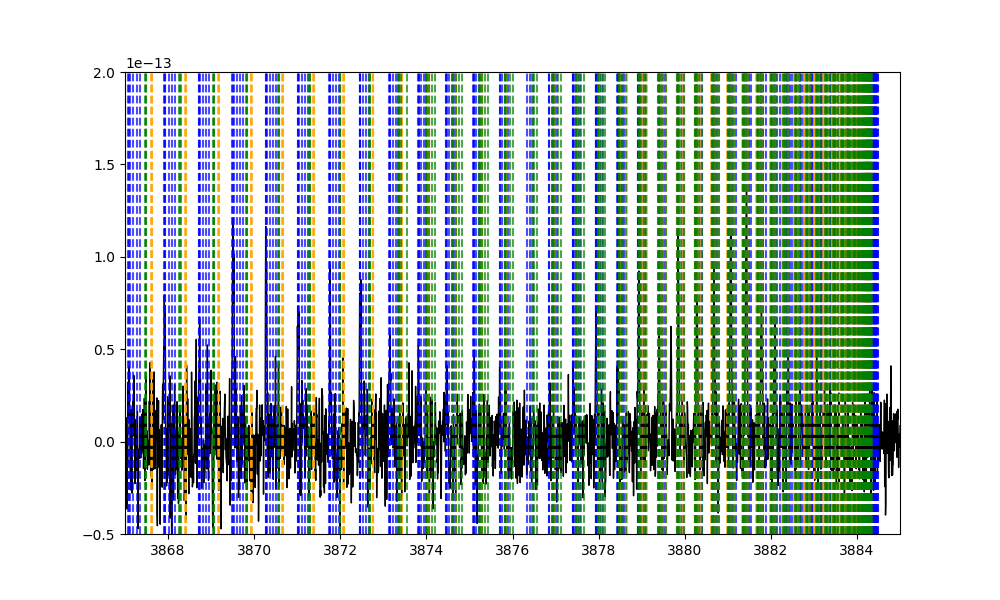

In [7]:

plt.figure(figsize=(10, 6))
plt.plot(spectra['WAVE'], spectra['FLUX_STACK'], label='Spectrum', color='black', lw=1)
for i in lines_cn_12:
    plt.axvline(i, color='blue', linestyle='--', alpha=0.7, label='CN 12C14N' if i == lines_cn_12[0] else "")
for i in lines_cn_13:
    plt.axvline(i, color='orange', linestyle='--', alpha=0.7, label='CN 13C14N' if i == lines_cn_13[0] else "")
for i in lines_cn_15:
    plt.axvline(i, color='green', linestyle='--', alpha=0.7, label='CN 12C15N' if i == lines_cn_15[0] else "")
# for i in lines_atomic_iron:
#     plt.axvline(i, color='red', linestyle=':', alpha=0.7, label='Fe I' if i == lines_atomic_iron[0] else "")
plt.xlim(3867, 3885)
plt.ylim(-5e-14, 2e-13)
plt.show()

#### now lets get the mean values for that nigth the most important in this case is r_au as is going to be used for the incident solar flux calculation at the comet position you can replace this by having r and rdot values

load_ephemeris_summary allows you to create a dict for different with the mean values for the comet and get_ephemeris_for_nights allows you to filter one night dict from all the nights

In [ ]:
from pathlib import Path
path = Path('Ephemeris/ephemeris_means_by_observation.csv')
#you could use the key_column kwarg to set another column as key default is 'date_obs', if is not there schange it as neede
ephemeris_all = helper.load_ephemeris_summary(path)
ephemeris_all
mean_values = helper.get_ephemeris_for_night(ephemeris_all, night)

mean_values

{'date_obs': 20250924,
 'n_exposures': 3,
 'ephemeris_file': 'Ephemeris/horizons_results_20250924.txt',
 'mean_jd_ut': 2460943.4863425926,
 'mean_dra_cosdec_arcsec_per_hr': -73.40633333333334,
 'mean_ddec_arcsec_per_hr': 18.190626666666663,
 'mean_t_mag': 15.507666666666665,
 'mean_r_au': 1.8492717459746668,
 'mean_rdot_km_s': -42.52747686666666,
 'mean_delta_au': 2.5189498192818296,
 'mean_deldot_km_s': -4.3657516,
 'mean_ra_deg': 219.31738194861111,
 'mean_dec_deg': -11.631675350000002,
 'mean_MJD': 60942.986342592594}

#### Remember the previous cell is optional, if you want to have r, delta, rdot, deltadot, or any other usefull value you can create your own dict, list, etc... with that values

# Now lets get the values of the solar irradiance that night

## 2 Options here:
 1) Load pre-calculated solar fluxes at the comet distance (I previously fitted a little delta lambda up the solar velocity to match the solar lines in the comet spectrum, so I used that solar irradiance here)
 2) Load the solar flux at 1 au (Kurucz)and shift it according to the comet from your machine or using the one stored in the package, for this is important to be concistent with the units, the default kurucz in the module is in u.AA and u.erg / (u.s * u.cm**2 * u.AA)


##### Option 1

In [26]:
# For this option there are kwargs to load different column names, name formats, etc...

solar = helper.load_pumping_file(night=night, directory='Pumping_files', scale_by_r_au=mean_values['mean_r_au'])

##### Option 2

In [23]:
import pandas as pd
import numpy as np

from astropy import constants as c
from astropy import units as u
# Option 2a: load from a local file shift the wavelength accordingly by the rdot andscale with the distance:
# solar = pd.DataFrame({'WAVE': wave_shifted, 'FLUX': flux/rdot**2})

#Option 2b: load from the preloaded file in the package

# Another option is using the preloaded kurucz in the helper
kurucz = helper.open_kurucz_irradiance()
wave = kurucz['WAVE']
flux = kurucz['FLUX']

beta   =  mean_values['mean_rdot_km_s']/ c.c.to(u.km / u.s).value
factor = np.sqrt((1.0 + beta) / (1.0 - beta))

wave_shifted = wave * factor
solar = pd.DataFrame({'WAVE': wave_shifted, 'FLUX': flux/mean_values['mean_r_au']**2})

This are the most important functions iin this submodule, there are another ones, but mainly to find paths, list files, etc...

### The modeling submodule has a lot of good functions I recomend to check it out, however almost all of them are used with the fluorescence submodule so we are going to focus there.